# Task 1 — Heritage Crack Classification

**Model:** EfficientNet-B4 (ImageNet pretrained, fine-tuned)  
**Dataset:** HistoricalCrack (757 cracked / 3139 intact, 1:4 imbalance)  
**Target:** Accuracy > 95%, AUC-ROC > 0.98  

**Runtime required:** T4 GPU (`Runtime > Change runtime type > T4 GPU`)

In [ ]:
import torch
assert torch.cuda.is_available(), "No GPU detected — Runtime > Change runtime type > T4 GPU"
print(f"GPU   : {torch.cuda.get_device_name(0)}")
print(f"VRAM  : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"CUDA  : {torch.version.cuda}")
print(f"PyTorch: {torch.__version__}")

GPU   : Tesla T4
VRAM  : 15.6 GB
CUDA  : 12.8
PyTorch: 2.10.0+cu128


In [ ]:
!pip install -q albumentations==1.4.3

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.0/137.0 kB 4.0 MB/s eta 0:00:00


## 1. Mount Drive & Prepare Data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path

# ── Paths (adjust DRIVE_DIR if your folder name differs) ────────────────────
DRIVE_DIR  = Path('/content/drive/MyDrive/HeritagePreservation')
DATA_DIR   = Path('/content/data')
CKPT_DIR   = Path('/content/checkpoints/classifier')
PLOTS_DIR  = Path('/content/plots/classifier')

for d in [DATA_DIR, CKPT_DIR, PLOTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("Drive contents:")
for f in sorted(DRIVE_DIR.iterdir()):
    print(f"  {f.name}")

Mounted at /content/drive
Drive contents:
  crackforest.zip
  historical_crack.zip
  masonry.zip
  omnicrack30k.zip


In [ ]:
import zipfile

zip_path = DRIVE_DIR / 'historical_crack.zip'
print(f"Unzipping {zip_path.name} ({zip_path.stat().st_size / 1e6:.1f} MB)...")
with zipfile.ZipFile(zip_path, 'r') as zf:
    zf.extractall(DATA_DIR)
print("Done.")

# Find dataset root — handles both zip layouts
DATA_ROOT = DATA_DIR / 'historical_crack'
if not DATA_ROOT.exists():
    DATA_ROOT = DATA_DIR  # extracted directly without subdirectory

intact_count  = len(list((DATA_ROOT / 'intact').glob('*.*')))
cracked_count = len(list((DATA_ROOT / 'cracked').glob('*.*')))
print(f"\nDataset root : {DATA_ROOT}")
print(f"intact       : {intact_count}")
print(f"cracked      : {cracked_count}")
print(f"total        : {intact_count + cracked_count}")
print(f"imbalance    : 1:{intact_count/cracked_count:.1f}")

Unzipping historical_crack.zip (17.3 MB)...
Done.

Dataset root : /content/data/historical_crack
intact       : 3139
cracked      : 757
total        : 3896
imbalance    : 1:4.1


## 2. Dataset & Transforms

In [ ]:
import cv2
import numpy as np
from sklearn.model_selection import train_test_split
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torch.utils.data import Dataset

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)
CLASSES = ['intact', 'cracked']  # 0 = intact, 1 = cracked


def get_transforms(split, img_size=224):
    if split == 'train':
        return A.Compose([
            A.Resize(img_size, img_size),
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.3),
            A.RandomRotate90(p=0.3),
            A.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.1, p=0.5),
            A.GaussNoise(p=0.2),
            A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
            ToTensorV2(),
        ])
    return A.Compose([
        A.Resize(img_size, img_size),
        A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ToTensorV2(),
    ])


class HistoricalCrackDataset(Dataset):
    def __init__(self, root, split='train', img_size=224, transform=None,
                 val_ratio=0.15, test_ratio=0.15, random_state=42):
        assert split in ('train', 'val', 'test')
        root = Path(root)
        all_paths, all_labels = [], []
        for label_idx, cls in enumerate(CLASSES):
            cls_dir = root / cls
            paths = sorted(cls_dir.glob('*.jpg')) + sorted(cls_dir.glob('*.png'))
            all_paths.extend(paths)
            all_labels.extend([label_idx] * len(paths))

        train_paths, tmp_paths, train_labels, tmp_labels = train_test_split(
            all_paths, all_labels, test_size=val_ratio + test_ratio,
            stratify=all_labels, random_state=random_state)
        adj = val_ratio / (val_ratio + test_ratio)
        val_paths, test_paths, val_labels, test_labels = train_test_split(
            tmp_paths, tmp_labels, test_size=1 - adj,
            stratify=tmp_labels, random_state=random_state)

        splits = {'train': (train_paths, train_labels),
                  'val':   (val_paths,   val_labels),
                  'test':  (test_paths,  test_labels)}
        self.paths, self.labels = splits[split]
        self.transform = transform or get_transforms(split, img_size)
        counts = np.bincount(self.labels)
        self.class_weights = len(self.labels) / (len(CLASSES) * counts)

    def __len__(self): return len(self.paths)

    def __getitem__(self, idx):
        img = cv2.imread(str(self.paths[idx]))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        return self.transform(image=img)['image'], self.labels[idx]

print("Dataset class ready.")

Dataset class ready.


## 3. Model

In [ ]:
import torch.nn as nn
import torchvision.models as models

INPUT_SIZES = {'resnet50': 224, 'efficientnet_b4': 380}


def build_classifier(model_name='efficientnet_b4', num_classes=2, pretrained=True):
    weights_arg = 'IMAGENET1K_V1' if pretrained else None
    if model_name == 'efficientnet_b4':
        model = models.efficientnet_b4(weights=weights_arg)
        in_features = model.classifier[1].in_features
        model.classifier[1] = nn.Linear(in_features, num_classes)
    elif model_name == 'resnet50':
        model = models.resnet50(weights=weights_arg)
        model.fc = nn.Linear(model.fc.in_features, num_classes)
    else:
        raise ValueError(f'Unknown model: {model_name}')
    return model

print("Model factory ready.")

Model factory ready.


## 4. Utilities

In [ ]:
import json
import matplotlib.pyplot as plt
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                              classification_report, confusion_matrix,
                              ConfusionMatrixDisplay)


def compute_metrics(labels, preds, probs):
    return {
        'accuracy': float(accuracy_score(labels, preds)),
        'f1':       float(f1_score(labels, preds, average='binary')),
        'auc_roc':  float(roc_auc_score(labels, probs[:, 1])),
    }


def plot_training_curves(history, out_dir):
    out_dir = Path(out_dir)
    epochs = range(1, len(history['train_loss']) + 1)
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    axes[0].plot(epochs, history['train_loss'], label='train')
    axes[0].plot(epochs, history['val_loss'],   label='val')
    axes[0].set_title('Loss'); axes[0].legend()
    axes[1].plot(epochs, history['train_acc'], label='train')
    axes[1].plot(epochs, history['val_acc'],   label='val')
    axes[1].set_title('Accuracy'); axes[1].legend()
    axes[2].plot(epochs, history['val_f1'],      label='F1')
    axes[2].plot(epochs, history['val_auc_roc'], label='AUC-ROC')
    axes[2].set_title('Val Metrics'); axes[2].legend()
    plt.tight_layout()
    plt.savefig(out_dir / 'training_curves.png', dpi=150)
    plt.show()


class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.gradients = None
        self.activations = None
        target_layer.register_forward_hook(self._save_activation)
        target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, inp, out): self.activations = out.detach()
    def _save_gradient(self, module, gi, go):     self.gradients = go[0].detach()

    def __call__(self, x, class_idx=None):
        self.model.eval()
        logits = self.model(x)
        if class_idx is None:
            class_idx = logits.argmax(dim=1).item()
        self.model.zero_grad()
        logits[0, class_idx].backward()
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * self.activations).sum(dim=1, keepdim=True)
        cam = torch.relu(cam).squeeze().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam

    @staticmethod
    def overlay(image_rgb, cam, alpha=0.4):
        h, w = image_rgb.shape[:2]
        cam_r = cv2.resize(cam, (w, h))
        heatmap = cv2.applyColorMap((cam_r * 255).astype(np.uint8), cv2.COLORMAP_JET)
        heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
        return (alpha * heatmap + (1 - alpha) * image_rgb).astype(np.uint8)

print("Utilities ready.")

Utilities ready.


## 5. Training

In [ ]:
import random

# ── Config ───────────────────────────────────────────────────────────────────
MODEL_NAME  = 'efficientnet_b4'
EPOCHS      = 30
BATCH_SIZE  = 16   # T4 memory limit with AMP; effective = BATCH_SIZE * ACCUM_STEPS
ACCUM_STEPS = 2    # gradient accumulation → effective batch = 32
LR          = 1e-4
SEED        = 42
NUM_WORKERS = 2
# ─────────────────────────────────────────────────────────────────────────────

DEVICE   = torch.device('cuda')
IMG_SIZE = INPUT_SIZES[MODEL_NAME]

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

print(f"Model        : {MODEL_NAME}")
print(f"Input        : {IMG_SIZE}x{IMG_SIZE}")
print(f"Epochs       : {EPOCHS}")
print(f"Batch        : {BATCH_SIZE} x {ACCUM_STEPS} accum = {BATCH_SIZE*ACCUM_STEPS} effective")
print(f"Device       : {DEVICE}")
print(f"AMP          : enabled")

Model        : efficientnet_b4
Input        : 380x380
Epochs       : 30
Batch        : 16 x 2 accum = 32 effective
Device       : cuda
AMP          : enabled


In [ ]:
from torch.utils.data import DataLoader, WeightedRandomSampler

train_ds = HistoricalCrackDataset(DATA_ROOT, split='train', img_size=IMG_SIZE, random_state=SEED)
val_ds   = HistoricalCrackDataset(DATA_ROOT, split='val',   img_size=IMG_SIZE, random_state=SEED)
test_ds  = HistoricalCrackDataset(DATA_ROOT, split='test',  img_size=IMG_SIZE, random_state=SEED)

print(f"Train   : {len(train_ds)}")
print(f"Val     : {len(val_ds)}")
print(f"Test    : {len(test_ds)}")
print(f"Class weights (intact / cracked): {train_ds.class_weights}")

sample_weights = [train_ds.class_weights[l] for l in train_ds.labels]
sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

Train   : 2727
Val     : 584
Test    : 585
Class weights (intact / cracked): [0.62061903 2.57264151]


In [ ]:
model = build_classifier(MODEL_NAME, num_classes=2, pretrained=True).to(DEVICE)

class_weights_t = torch.tensor(train_ds.class_weights, dtype=torch.float32).to(DEVICE)
criterion  = nn.CrossEntropyLoss(weight=class_weights_t)
optimizer  = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler  = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

total_params = sum(p.numel() for p in model.parameters())
train_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params    : {total_params:,}")
print(f"Trainable params: {train_params:,}")

Downloading: "https://download.pytorch.org/models/efficientnet_b4_rwightman-23ab8bcd.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b4_rwightman-23ab8bcd.pth


100%|██████████| 74.5M/74.5M [00:00<00:00, 129MB/s]


Total params    : 17,552,202
Trainable params: 17,552,202


In [ ]:
from tqdm.notebook import tqdm
from torch.amp import GradScaler, autocast

scaler = GradScaler('cuda')


def run_epoch(model, loader, criterion, optimizer, train):
    model.train() if train else model.eval()
    total_loss, all_preds, all_labels, all_probs = 0.0, [], [], []

    if train:
        optimizer.zero_grad()

    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for step, (images, labels) in enumerate(tqdm(loader, leave=False)):
            images, labels = images.to(DEVICE), labels.to(DEVICE)

            with autocast('cuda'):
                logits = model(images)
                loss = criterion(logits, labels)

            if train:
                scaler.scale(loss / ACCUM_STEPS).backward()
                if (step + 1) % ACCUM_STEPS == 0 or (step + 1) == len(loader):
                    scaler.step(optimizer)
                    scaler.update()
                    optimizer.zero_grad()

            total_loss += loss.item() * len(labels)
            probs = torch.softmax(logits.float(), dim=1).detach().cpu().numpy()
            all_probs.extend(probs)
            all_preds.extend(probs.argmax(axis=1))
            all_labels.extend(labels.cpu().numpy())

    all_labels = np.array(all_labels)
    all_preds  = np.array(all_preds)
    all_probs  = np.array(all_probs)
    m = compute_metrics(all_labels, all_preds, all_probs)
    m['loss'] = total_loss / len(all_labels)
    return m


torch.cuda.empty_cache()
history = {k: [] for k in ['train_loss', 'train_acc', 'val_loss',
                             'val_acc', 'val_f1', 'val_auc_roc']}
best_f1 = 0.0

for epoch in range(1, EPOCHS + 1):
    tr = run_epoch(model, train_loader, criterion, optimizer, train=True)
    va = run_epoch(model, val_loader,   criterion, None,      train=False)
    scheduler.step()

    for k, v in [('train_loss', tr['loss']), ('train_acc', tr['accuracy']),
                 ('val_loss',   va['loss']), ('val_acc',   va['accuracy']),
                 ('val_f1',     va['f1']),   ('val_auc_roc', va['auc_roc'])]:
        history[k].append(v)

    print(f"[{epoch:02d}/{EPOCHS}] "
          f"loss={tr['loss']:.4f} acc={tr['accuracy']:.4f} | "
          f"val_loss={va['loss']:.4f} val_acc={va['accuracy']:.4f} "
          f"val_f1={va['f1']:.4f} val_auc={va['auc_roc']:.4f}")

    if va['f1'] > best_f1:
        best_f1 = va['f1']
        torch.save({'epoch': epoch, 'model_state': model.state_dict(),
                    'val_f1': best_f1, 'val_acc': va['accuracy'],
                    'model_name': MODEL_NAME, 'img_size': IMG_SIZE},
                   CKPT_DIR / 'best.pth')
        print(f"   -> best saved (val_f1={best_f1:.4f})")

torch.save({'epoch': EPOCHS, 'model_state': model.state_dict(),
            'model_name': MODEL_NAME}, CKPT_DIR / 'last.pth')
print("\nTraining complete!")

  0%|          | 0/171 [00:00<?, ?it/s]

  0%|          | 0/37 [00:00<?, ?it/s]

[01/30] loss=0.4254 acc=0.5277 | val_loss=0.4019 val_acc=0.7260 val_f1=0.5833 val_auc=0.9885
   -> best saved (val_f1=0.5833)


  0%|          | 0/171 [00:00<?, ?it/s]

  0%|          | 0/37 [00:00<?, ?it/s]

...

  0%|          | 0/37 [00:00<?, ?it/s]

[29/30] loss=0.0041 acc=0.9989 | val_loss=0.0298 val_acc=0.9932 val_f1=0.9825 val_auc=0.9997


  0%|          | 0/171 [00:00<?, ?it/s]

  0%|          | 0/37 [00:00<?, ?it/s]

[30/30] loss=0.0059 acc=0.9978 | val_loss=0.0314 val_acc=0.9932 val_f1=0.9825 val_auc=0.9997

Training complete!


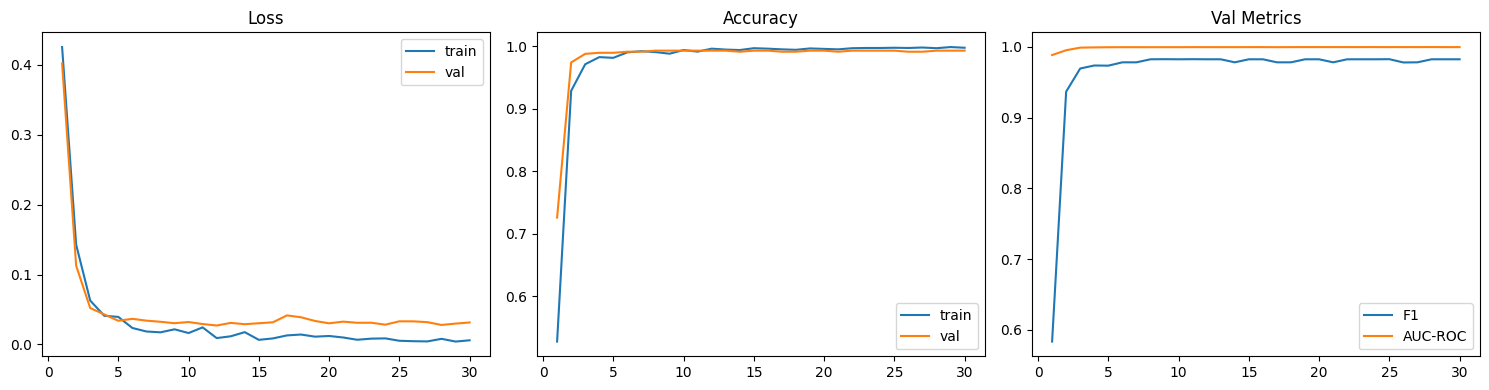

In [ ]:
plot_training_curves(history, PLOTS_DIR)

## 6. Test Evaluation

In [ ]:
ckpt = torch.load(CKPT_DIR / 'best.pth', map_location=DEVICE)
model.load_state_dict(ckpt['model_state'])
model.eval()

all_preds, all_labels, all_probs = [], [], []
with torch.no_grad():
    for images, labels in tqdm(test_loader, desc='test', leave=False):
        probs = torch.softmax(model(images.to(DEVICE)), dim=1).cpu().numpy()
        all_probs.extend(probs)
        all_preds.extend(probs.argmax(axis=1))
        all_labels.extend(labels.numpy())

all_labels = np.array(all_labels)
all_preds  = np.array(all_preds)
all_probs  = np.array(all_probs)

test_m = compute_metrics(all_labels, all_preds, all_probs)
print("=== Test Results ===")
print(f"Accuracy : {test_m['accuracy']:.4f}  (target >0.95)")
print(f"F1       : {test_m['f1']:.4f}")
print(f"AUC-ROC  : {test_m['auc_roc']:.4f}")
print()
print(classification_report(all_labels, all_preds, target_names=CLASSES))

history['test'] = test_m
with open(CKPT_DIR / 'history.json', 'w') as f:
    json.dump(history, f, indent=2)

test:   0%|          | 0/37 [00:00<?, ?it/s]

=== Test Results ===
Accuracy : 0.9983  (target >0.95)
F1       : 0.9956
AUC-ROC  : 1.0000

              precision    recall  f1-score   support

      intact       1.00      1.00      1.00       471
     cracked       0.99      1.00      1.00       114

    accuracy                           1.00       585
   macro avg       1.00      1.00      1.00       585
weighted avg       1.00      1.00      1.00       585



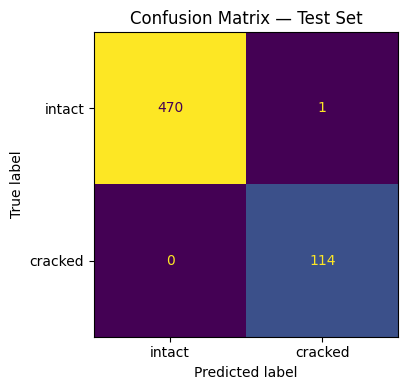

In [ ]:
cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm, display_labels=CLASSES).plot(ax=ax, colorbar=False)
plt.title('Confusion Matrix — Test Set')
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'confusion_matrix.png', dpi=150)
plt.show()

## 7. Grad-CAM Visualisation

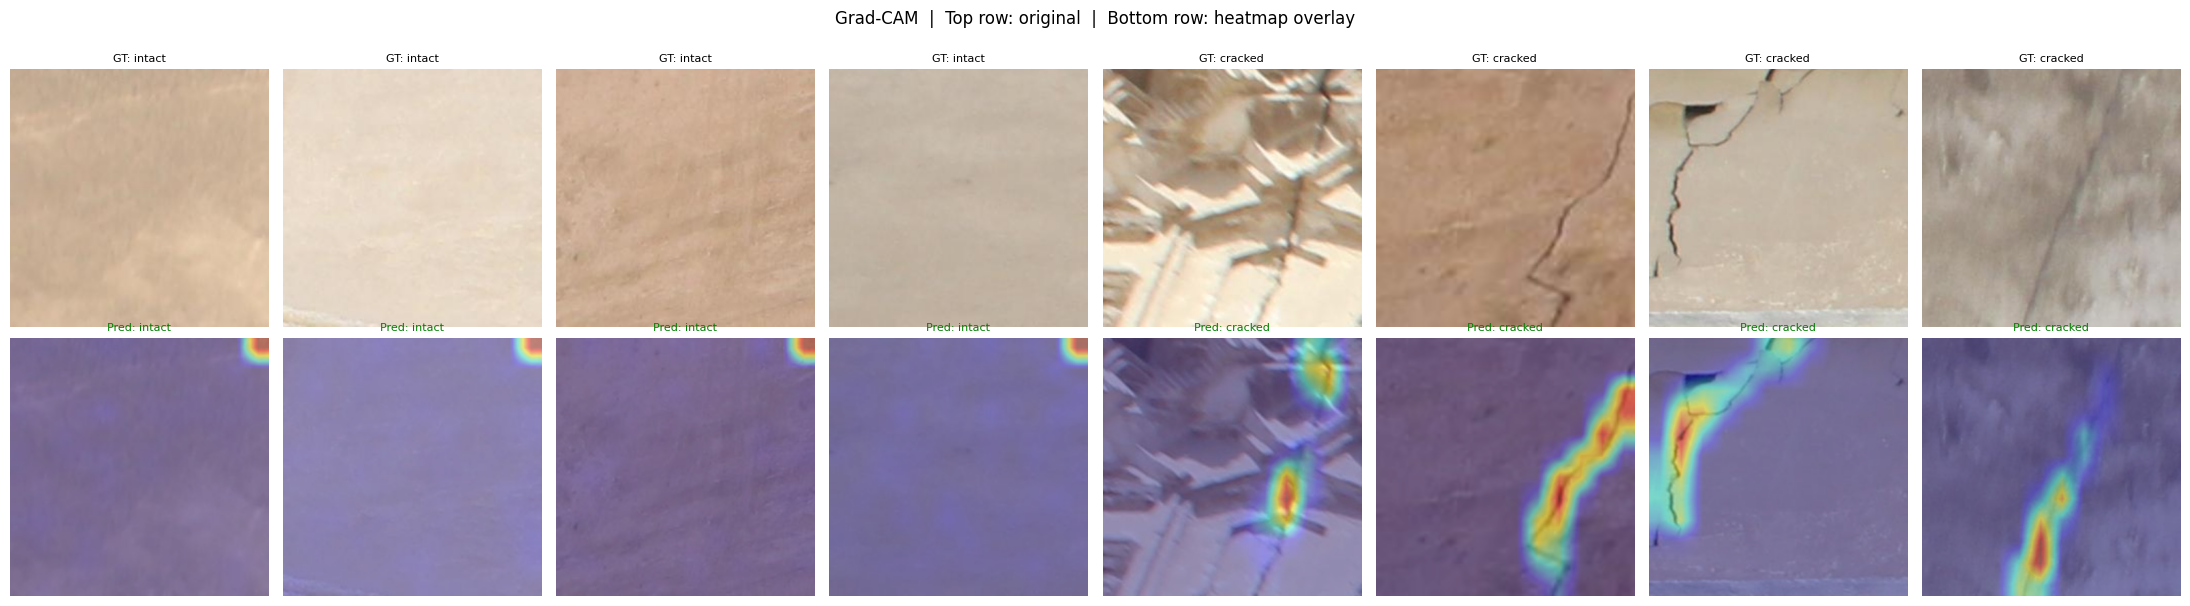

In [ ]:
# Target layer: last conv block of EfficientNet-B4
target_layer = model.features[-1]
grad_cam = GradCAM(model, target_layer)

# 4 intact + 4 cracked samples from test set
intact_idx  = [i for i, l in enumerate(test_ds.labels) if l == 0][:4]
cracked_idx = [i for i, l in enumerate(test_ds.labels) if l == 1][:4]
sample_idx  = intact_idx + cracked_idx

fig, axes = plt.subplots(2, 8, figsize=(22, 6))
fig.suptitle('Grad-CAM  |  Top row: original  |  Bottom row: heatmap overlay', y=1.01)

for col, idx in enumerate(sample_idx):
    img_tensor, true_label = test_ds[idx]

    raw = cv2.imread(str(test_ds.paths[idx]))
    raw = cv2.cvtColor(raw, cv2.COLOR_BGR2RGB)
    raw = cv2.resize(raw, (IMG_SIZE, IMG_SIZE))

    x = img_tensor.unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        pred_idx = model(x).argmax(dim=1).item()
    cam = grad_cam(x, class_idx=pred_idx)
    overlay = GradCAM.overlay(raw, cam)

    correct = pred_idx == true_label
    axes[0, col].imshow(raw)
    axes[0, col].set_title(f"GT: {CLASSES[true_label]}", fontsize=8)
    axes[0, col].axis('off')
    axes[1, col].imshow(overlay)
    axes[1, col].set_title(f"Pred: {CLASSES[pred_idx]}", fontsize=8,
                            color='green' if correct else 'red')
    axes[1, col].axis('off')

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'gradcam.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Save Results to Drive

In [ ]:
import shutil

DRIVE_CKPT  = DRIVE_DIR / 'checkpoints' / 'classifier'
DRIVE_PLOTS = DRIVE_DIR / 'plots' / 'classifier'
DRIVE_CKPT.mkdir(parents=True,  exist_ok=True)
DRIVE_PLOTS.mkdir(parents=True, exist_ok=True)

for f in CKPT_DIR.iterdir():
    shutil.copy2(f, DRIVE_CKPT / f.name)

for f in PLOTS_DIR.iterdir():
    shutil.copy2(f, DRIVE_PLOTS / f.name)

print("Saved checkpoints:")
for f in sorted(DRIVE_CKPT.iterdir()):
    size = f.stat().st_size / 1e6
    print(f"  {f.name:30s}  {size:.1f} MB")

print("\nSaved plots:")
for f in sorted(DRIVE_PLOTS.iterdir()):
    print(f"  {f.name}")

print(f"\nFinal test metrics:")
print(f"  Accuracy : {test_m['accuracy']:.4f}")
print(f"  F1       : {test_m['f1']:.4f}")
print(f"  AUC-ROC  : {test_m['auc_roc']:.4f}")

Saved checkpoints:
  best.pth                        70.9 MB
  history.json                    0.0 MB
  last.pth                        70.9 MB

Saved plots:
  confusion_matrix.png
  gradcam.png
  training_curves.png

Final test metrics:
  Accuracy : 0.9983
  F1       : 0.9956
  AUC-ROC  : 1.0000
